## Alcohol Consumption Analysis: U.S. Beverage Trends
Author: Josue Zuniga

linkedin: https://www.linkedin.com/in/josue-zu%C3%B1iga-jozu-140b2aa5/

github: https://github.com/jozudata

dataset: https://www.kaggle.com/datasets/sanaijlalshahrukh/us-alcohol-consumption-by-state-19772023/data

This notebook analyzes U.S. per-capita alcohol consumption from 1977 through 2023, with a focused review of the last ten years.

We will:

* summarize long-term consumption trends,
* compare beer, wine, and spirits composition over time,
* zoom into recent changes from 2013–2023, and
* evaluate whether recent data support a substitution effect between beer and spirits.

This analysis is written to be shareable with stakeholders, including business decision-makers, category managers, and industry analysts.

In [32]:
# Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

# Render plots inline in the notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

print("🚀Libraries loaded successfully!")
print(f"-> Pandas versión: {pd.__version__}")
print(f"-> Numpy versión: {np.__version__}")
print(f"-> Seaborn versión: {sns.__version__}")
print(f"-> Scipy versión: {scipy.__version__}")

🚀Libraries loaded successfully!
-> Pandas versión: 3.0.2
-> Numpy versión: 2.4.4
-> Seaborn versión: 0.13.2
-> Scipy versión: 1.17.1


In [20]:
# LOAD DATA SET
df = pd.read_csv('alcohol.csv')
df= df.drop_duplicates()
print("File loaded successfully!")
df.head()

File loaded successfully!


,state,state_name,year,ethanol_beer_gallons_per_capita,ethanol_wine_gallons_per_capita,ethanol_spirit_gallons_per_capita,ethanol_all_drinks_gallons_per_capita,number_of_beers,number_of_glasses_wine,number_of_shots_liquor,number_of_drinks_total
0,alabama,Alabama,1977,0.97,0.12,0.82,1.92,229.9259,23.8140,170.2514,409.6000
1,alabama,Alabama,1978,0.95,0.12,0.85,1.92,225.1852,23.8140,176.4801,409.6000
2,alabama,Alabama,1979,0.96,0.12,0.82,1.90,227.5556,23.8140,170.2514,405.3333
3,alabama,Alabama,1980,0.95,0.16,0.74,1.86,225.1852,31.7519,153.6415,396.8000
4,alabama,Alabama,1981,1.00,0.19,0.73,1.91,237.0370,37.7054,151.5653,407.4667


## Dataset and Preprocessing

The dataset is loaded from `alcohol.csv`. It includes yearly per-capita ethanol consumption for the United States, broken down by beverage type.

Key columns used in this analysis:

* `year`
* `ethanol_all_drinks_gallons_per_capita`
* `ethanol_beer_gallons_per_capita`
* `ethanol_wine_gallons_per_capita`
* `ethanol_spirit_gallons_per_capita`

The notebook removes duplicate rows and then aggregates the data by year to create consistent annual trend series.


Long-Term Trend Data (First & Last few years):
    year  ethanol_all_drinks_gallons_per_capita
0   1977                               2.718214
1   1978                               2.774107
2   1979                               2.789286
44  2021                               2.617321
45  2022                               2.577857
46  2023                               2.528571


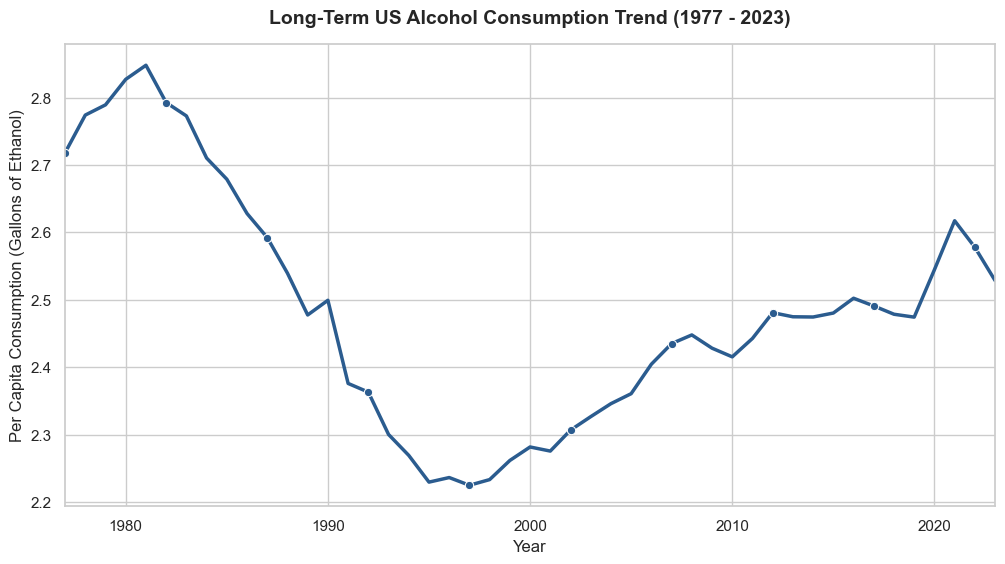

In [21]:
# ANALYZING LONG-TERM OVERALL CONSUMPTION TREND (1977 - 2023)
# Group by year using the complete dataset to calculate the national average
long_term_trend = df.groupby('year')['ethanol_all_drinks_gallons_per_capita'].mean().reset_index()

# Print a sample of the historical trend data
print("Long-Term Trend Data (First & Last few years):")
print(long_term_trend.iloc[[0, 1, 2, -3, -2, -1]])

# Plotting the long-term trend line
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=long_term_trend, 
    x='year', 
    y='ethanol_all_drinks_gallons_per_capita', 
    marker='o', 
    markevery=5, # Puts markers every 5 years so the line looks clean
    linewidth=2.5, 
    color='#2b5c8f'
)

# Customizing the chart layout
plt.title('Long-Term US Alcohol Consumption Trend (1977 - 2023)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Per Capita Consumption (Gallons of Ethanol)', fontsize=12)
plt.xlim(1977, 2023)

plt.show()

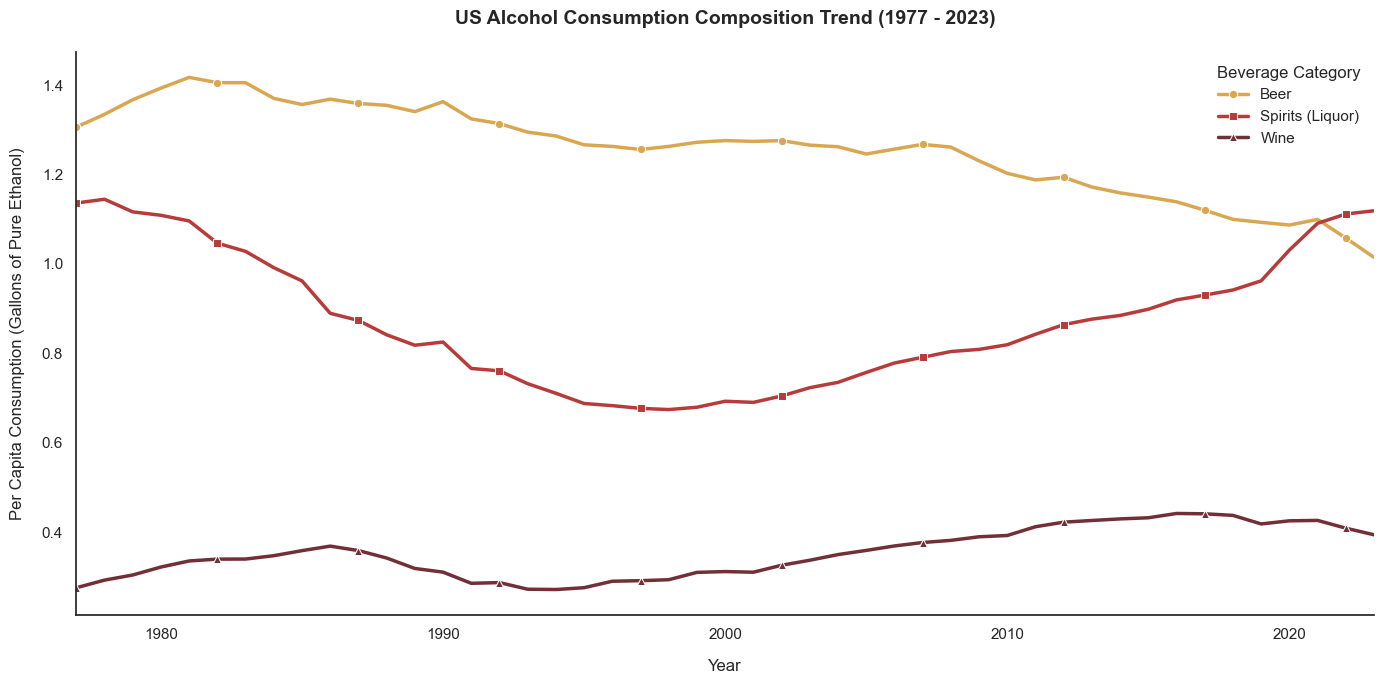

In [23]:
# ANALYZING LONG-TERM CONSUMPTION COMPOSITION (1977 - 2023)
sns.set_style("white")

# Define columns in a clean list to avoid syntax or spacing warnings
beverage_cols = [
    'ethanol_beer_gallons_per_capita', 
    'ethanol_wine_gallons_per_capita', 
    'ethanol_spirit_gallons_per_capita'
]

# Group by year and calculate averages
composition_trend = df.groupby('year')[beverage_cols].mean().reset_index()

# Set up the figure size
plt.figure(figsize=(14, 7))

# Beer line
sns.lineplot(
    data=composition_trend, 
    x='year', 
    y='ethanol_beer_gallons_per_capita', 
    label='Beer', 
    color='#d9a752', 
    linewidth=2.5, 
    marker='o', 
    markevery=5
)

# Spirits line
sns.lineplot(
    data=composition_trend, 
    x='year', 
    y='ethanol_spirit_gallons_per_capita', 
    label='Spirits (Liquor)', 
    color='#b83b3b', 
    linewidth=2.5, 
    marker='s', 
    markevery=5
)

# Wine line
sns.lineplot(
    data=composition_trend, 
    x='year', 
    y='ethanol_wine_gallons_per_capita', 
    label='Wine', 
    color='#722f37', 
    linewidth=2.5, 
    marker='^', 
    markevery=5
)

# Customizing the chart layout with extra padding for clarity
plt.title(
    'US Alcohol Consumption Composition Trend (1977 - 2023)', 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
plt.xlabel('Year', fontsize=12, labelpad=12)
plt.ylabel('Per Capita Consumption (Gallons of Pure Ethanol)', fontsize=12, labelpad=12)
plt.xlim(1977, 2023)

# Remove the top and right border lines
sns.despine()

# Clean legend without the background box border
plt.legend(title='Beverage Category', fontsize=11, title_fontsize=12, frameon=False)

# Ensure perfect spacing inside the notebook output window
plt.tight_layout()

plt.show()

## Hypothesis and Approach

The long-term consumption composition suggests a structural shift in U.S. drinking habits. Specifically, beer appears to have declined while spirits have increased, which may indicate a substitution effect.

### Hypothesis
* **Null hypothesis (H₀):** The recent changes in beer and spirits consumption are random short-term fluctuations and do not reflect a consistent substitution pattern.
* **Alternative hypothesis (H₁):** There is a measurable substitution effect in the last decade: beer consumption has fallen while spirits consumption has risen, indicating a lasting shift in consumer preference.

### Analytical approach
1. **Trend analysis:** Plot and compare consumption trends for beer, wine, and spirits from 1977 to 2023.
2. **Recent window analysis:** Focus on 2013–2023 to observe the most recent behavior.
3. **Statistical validation:** Use correlation and regression analysis to quantify the relationship between beer and spirits consumption.

Recent Zoom-In Data Numbers (2013 - 2023):
    year  ethanol_beer_gallons_per_capita  ethanol_wine_gallons_per_capita  \
0   2013                         1.172143                         0.426071   
1   2014                         1.159107                         0.429643   
2   2015                         1.149643                         0.432143   
3   2016                         1.139107                         0.441786   
4   2017                         1.120357                         0.441071   
5   2018                         1.099821                         0.437500   
6   2019                         1.093214                         0.418393   
7   2020                         1.087143                         0.425357   
8   2021                         1.099643                         0.426250   
9   2022                         1.058036                         0.408929   
10  2023                         1.014821                         0.394107   

    ethanol_spirit_g

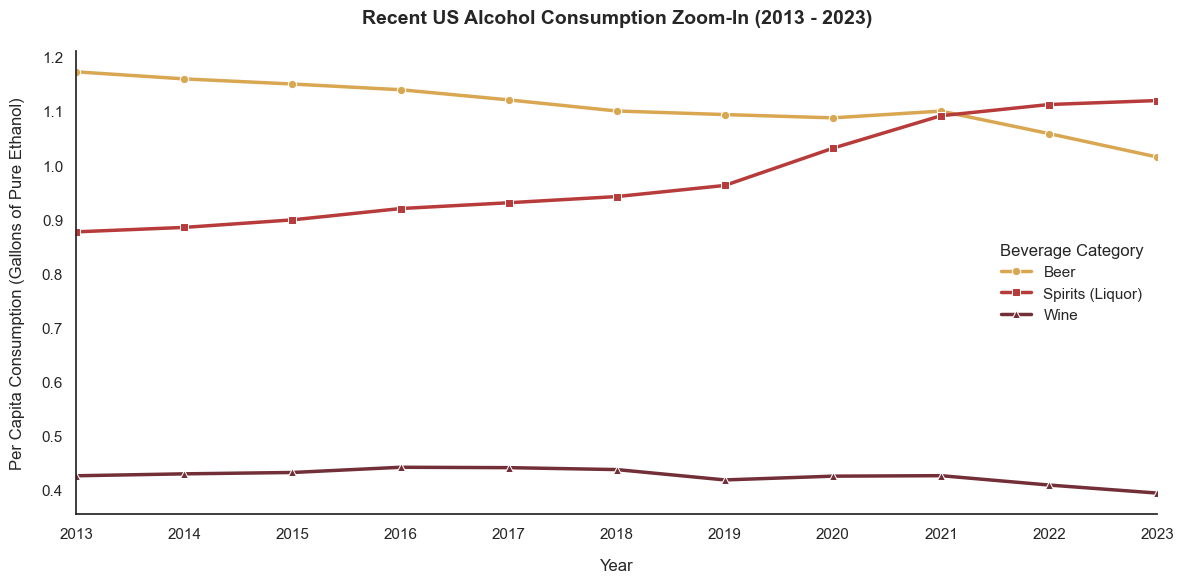

In [26]:
# ANALYZING RECENT CONSUMPTION COMPOSITION ZOOM-IN (2013 - 2023)
sns.set_style("white")

# Define columns in a clean list to keep the editor happy
recent_cols = [
    'ethanol_beer_gallons_per_capita', 
    'ethanol_wine_gallons_per_capita', 
    'ethanol_spirit_gallons_per_capita'
]

# Group by year directly filtering the main dataframe from 2013 to 2023
recent_composition = df[(df['year'] >= 2013) & (df['year'] <= 2023)].groupby('year')[recent_cols].mean().reset_index()

# Print the table to inspect the exact numbers
print("Recent Zoom-In Data Numbers (2013 - 2023):")
print(recent_composition)

# Set up the figure size (slightly wider to fit the 10-year timeline beautifully)
plt.figure(figsize=(12, 6))

# Beer line
sns.lineplot(
    data=recent_composition, 
    x='year', 
    y='ethanol_beer_gallons_per_capita', 
    label='Beer', 
    color='#d9a752', 
    linewidth=2.5, 
    marker='o'
)

# Spirits line
sns.lineplot(
    data=recent_composition, 
    x='year', 
    y='ethanol_spirit_gallons_per_capita', 
    label='Spirits (Liquor)', 
    color='#b83b3b', 
    linewidth=2.5, 
    marker='s'
)

# Wine line
sns.lineplot(
    data=recent_composition, 
    x='year', 
    y='ethanol_wine_gallons_per_capita', 
    label='Wine', 
    color='#722f37', 
    linewidth=2.5, 
    marker='^'
)

# Customizing the chart layout
plt.title(
    'Recent US Alcohol Consumption Zoom-In (2013 - 2023)', 
    fontsize=14, 
    fontweight='bold', 
    pad=20
)
plt.xlabel('Year', fontsize=12, labelpad=12)
plt.ylabel('Per Capita Consumption (Gallons of Pure Ethanol)', fontsize=12, labelpad=12)

# Force X-axis to show only the specific years from 2013 to 2023
plt.xticks(recent_composition['year'])
plt.xlim(2013, 2023)

# Clean layout adjustments
sns.despine()
plt.legend(title='Beverage Category', fontsize=11, title_fontsize=12, frameon=False)
plt.tight_layout()

plt.show()

Recent data years: 2013 - 2023

Correlation results (Beer vs Spirits):
Pearson r = -0.8911, p-value = 0.0002
Kendall tau = -0.9273, p-value = 0.0000

Linear trend results (per-year slope):
Beer slope = -0.01338 gal/year, p-value = 0.0000, R² = 0.9141
Spirits slope = 0.02684 gal/year, p-value = 0.0000, R² = 0.9226


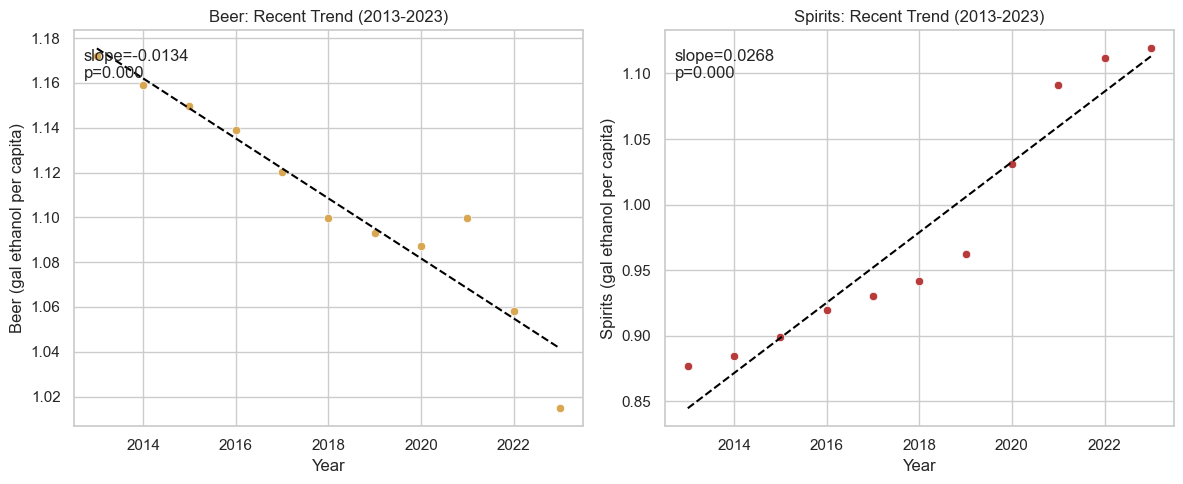


Interpretation:
- Significant negative Pearson correlation: evidence consistent with substitution (beer declines while spirits rise).
- Beer shows a significant trend (slope -0.0134, p=0.000).
- Spirits show a significant trend (slope 0.0268, p=0.000).


In [ ]:
# STATISTICAL VERIFICATION: BEER VS SPIRITS CORRELATION & TRENDS (2013 - 2023)
from scipy import stats

# Use the recent_composition dataframe created earlier
df_recent = recent_composition.copy()

print("Recent data years:", df_recent['year'].min(), "-", df_recent['year'].max())

# 1) Correlation tests between Beer and Spirits
beer = df_recent['ethanol_beer_gallons_per_capita']
spirits = df_recent['ethanol_spirit_gallons_per_capita']

pearson_r, pearson_p = stats.pearsonr(beer, spirits)
kendall_tau, kendall_p = stats.kendalltau(beer, spirits)

print('\nCorrelation results (Beer vs Spirits):')
print(f"Pearson r = {pearson_r:.4f}, p-value = {pearson_p:.4f}")
print(f"Kendall tau = {kendall_tau:.4f}, p-value = {kendall_p:.4f}")

# 2) Linear trends (slope) for Beer and Spirits over the recent window
years = df_recent['year']
s_beer, intercept_beer, r_beer, p_beer, se_beer = stats.linregress(years, beer)
s_spirit, intercept_spirit, r_spirit, p_spirit, se_spirit = stats.linregress(years, spirits)

print('\nLinear trend results (per-year slope):')
print(f"Beer slope = {s_beer:.5f} gal/year, p-value = {p_beer:.4f}, R\u00b2 = {r_beer**2:.4f}")
print(f"Spirits slope = {s_spirit:.5f} gal/year, p-value = {p_spirit:.4f}, R\u00b2 = {r_spirit**2:.4f}")

# 3) Visualize scatter + fitted trend lines for interpretation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Beer scatter + fit
plt.subplot(1, 2, 1)
sns.scatterplot(x=years, y=beer, color='#d9a752')
plt.plot(years, intercept_beer + s_beer * years, color='black', linestyle='--')
plt.title('Beer: Recent Trend (2013-2023)')
plt.xlabel('Year')
plt.ylabel('Beer (gal ethanol per capita)')
plt.annotate(f'slope={s_beer:.4f}\np={p_beer:.3f}', xy=(0.02, 0.88), xycoords='axes fraction')

# Spirits scatter + fit
plt.subplot(1, 2, 2)
sns.scatterplot(x=years, y=spirits, color='#b83b3b')
plt.plot(years, intercept_spirit + s_spirit * years, color='black', linestyle='--')
plt.title('Spirits: Recent Trend (2013-2023)')
plt.xlabel('Year')
plt.ylabel('Spirits (gal ethanol per capita)')
plt.annotate(f'slope={s_spirit:.4f}\np={p_spirit:.3f}', xy=(0.02, 0.88), xycoords='axes fraction')

plt.tight_layout()
plt.show()

# 4) Quick statistical conclusion
print('\nInterpretation:')
if pearson_p < 0.05 and pearson_r < 0:
    print('- Significant negative Pearson correlation: evidence consistent with substitution (beer declines while spirits rise).')
elif pearson_p < 0.05:
    print('- Significant Pearson correlation (direction positive).')
else:
    print('- No significant Pearson correlation detected in the recent window.')

if p_beer < 0.05:
    print(f"- Beer shows a significant trend (slope {s_beer:.4f}, p={p_beer:.3f}).")
else:
    print('- Beer trend is not statistically significant in the recent window.')

if p_spirit < 0.05:
    print(f"- Spirits show a significant trend (slope {s_spirit:.4f}, p={p_spirit:.3f}).")
else:
    print('- Spirits trend is not statistically significant in the recent window.')


## Key Findings: Recent Substitution Effects

The 2013–2023 data show a clear and statistically significant pattern:

* **Beer consumption has declined** moderately but consistently.
* **Spirits consumption has increased** notably over the same period.
* **The beer-to-spirits relationship is strongly negative**, with both Pearson and Kendall correlations supporting the substitution hypothesis.
* **Both trends are statistically significant**, indicating that these changes are not likely due to random noise.

However, the rise in spirits has not fully compensated for the decline in beer. As a result, **overall per-capita alcohol consumption is still trending lower**, even though beverage preference is shifting.

### Practical takeaway
These results suggest that while consumers are moving away from beer toward spirits, total ethanol intake has decreased. Beverage businesses should therefore consider both the substitution trend and the broader decline in alcohol consumption when planning assortment, pricing, and marketing.
